# Personalization signal analysis

**Purpose:** decide, from real Silver data, which customer-level signals justify a `gold.customer_personalization_profile` table -- before designing that table.

This does not build the recommender or the Gold table. It measures, for every candidate personalization signal the team discussed:

- **Coverage** -- what fraction of the 150,000 customers actually have the signal at all.
- **Consistency** -- when the same fact is recorded in more than one table (e.g. accent), do the sources agree?
- **Domain** -- the real distinct values, not the ones assumed from the data dictionary.
- **Language reality** -- the hackathon requires Spanish *and* Portuguese; this checks what the dataset actually contains before any Portuguese-specific personalization is designed.

Risk-scoring signals (`credit_score`, `estimated_monthly_income`, `fraud_score`, `days_past_due`) are deliberately **out of scope** -- the team decided personalization should not run through those fields.

Reads `silver.*` tables only, read-only connection, no writes.

In [1]:
import os
import warnings
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import pandas as pd

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 110

# Same PROJECT_ROOT/DATA_DIR/DUCKDB_PATH resolution convention as the rest of the pipeline.
SCRIPT_DIR = Path.cwd()
PROJECT_ROOT = Path(os.environ.get("PROJECT_ROOT", SCRIPT_DIR.parent.parent)).resolve()
DATA_DIR = Path(os.environ.get("DATA_DIR", PROJECT_ROOT / "data")).resolve()
DUCKDB_PATH = Path(os.environ.get("DUCKDB_PATH", DATA_DIR / "latam_bank.duckdb"))
print("Using DuckDB file:", DUCKDB_PATH)

con = duckdb.connect(str(DUCKDB_PATH), read_only=True)
temp_dir = DATA_DIR / "duckdb_tmp"
temp_dir.mkdir(parents=True, exist_ok=True)
con.execute("SET memory_limit='3GB'")
con.execute("SET temp_directory=?", [str(temp_dir)])
con.execute("SET threads=2")

total_customers = con.execute("SELECT count(*) FROM silver.dim_customers").fetchone()[0]
print(f"Total customers: {total_customers:,}")

Using DuckDB file: C:\Users\andre\Desktop\Personal\Hackathones\Factored\branch-personalization\Factored-Hackathon-2026-ArabicaAI\data\latam_bank.duckdb
Total customers: 150,000


## 1. Signal coverage per customer (cold-start exposure)

How many of the 150,000 customers actually have each type of history at all? A signal with low coverage cannot personalize most customers' first contact.

In [2]:
coverage_queries = {
    "call_center_interactions": "SELECT count(DISTINCT customer_id) FROM silver.fact_call_center_interactions",
    "call_transcripts": "SELECT count(DISTINCT customer_id) FROM silver.fact_call_transcripts",
    "complaints": "SELECT count(DISTINCT customer_id) FROM silver.fact_complaints",
    "satisfaction_surveys": "SELECT count(DISTINCT customer_id) FROM silver.fact_satisfaction_surveys",
    "digital_events": "SELECT count(DISTINCT customer_id) FROM silver.fact_digital_events",
    "transactions": "SELECT count(DISTINCT customer_id) FROM silver.fact_transactions",
}
coverage = pd.DataFrame(
    [(name, con.execute(q).fetchone()[0]) for name, q in coverage_queries.items()],
    columns=["source", "customers_with_signal"],
)
coverage["pct_of_all_customers"] = (100 * coverage["customers_with_signal"] / total_customers).round(1)
coverage = coverage.sort_values("pct_of_all_customers", ascending=True)
coverage

,source,customers_with_signal,pct_of_all_customers
2,complaints,54145,36.1
1,call_transcripts,101951,68.0
3,satisfaction_surveys,113640,75.8
5,transactions,134515,89.7
0,call_center_interactions,148443,99.0
4,digital_events,149997,100.0


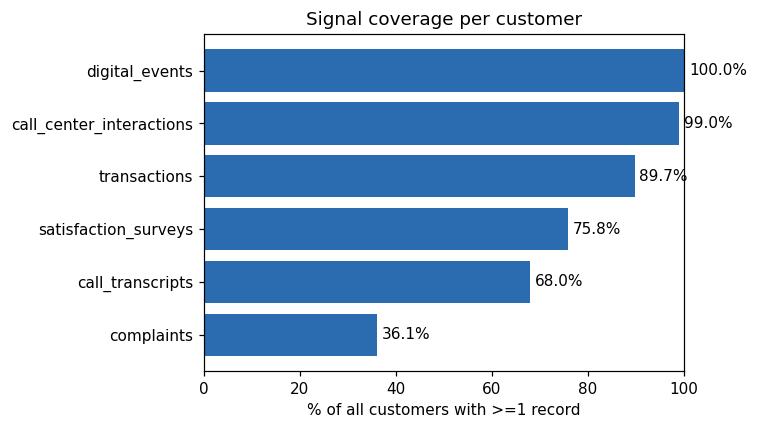

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(coverage["source"], coverage["pct_of_all_customers"], color="#2b6cb0")
ax.set_xlabel("% of all customers with >=1 record")
ax.set_title("Signal coverage per customer")
ax.set_xlim(0, 100)
for y, v in enumerate(coverage["pct_of_all_customers"]):
    ax.text(v + 1, y, f"{v}%", va="center")
plt.tight_layout()
plt.show()

In [4]:
cold = con.execute(
    """
    SELECT count(*) FROM silver.dim_customers c
    WHERE NOT EXISTS (SELECT 1 FROM silver.fact_call_center_interactions i WHERE i.customer_id = c.customer_id)
      AND NOT EXISTS (SELECT 1 FROM silver.fact_complaints cp WHERE cp.customer_id = c.customer_id)
      AND NOT EXISTS (SELECT 1 FROM silver.fact_digital_events d WHERE d.customer_id = c.customer_id)
    """
).fetchone()[0]
print(f"Customers with zero interactions, complaints, or digital events: {cold:,} "
      f"({100*cold/total_customers:.1f}% of {total_customers:,})")

Customers with zero interactions, complaints, or digital events: 0 (0.0% of 150,000)


**Reading:** every customer has at least one digital event or interaction, so there is no fully cold-start population. But coverage drops sharply for `complaints` (36%) and `call_transcripts` (68%) -- those two cannot be a customer's *only* personalization signal; they can only refine what `call_center_interactions` and `digital_events` already cover.

## 2. Accent signal: domain and cross-source agreement

The dataset records accent in three places. Do they agree enough to trust one as the source of truth?

In [5]:
accent_dim = pd.read_sql(
    "SELECT detected_accent, count(*) AS customers FROM silver.dim_customers GROUP BY 1 ORDER BY 2 DESC", con
)
accent_dim["detected_accent"] = accent_dim["detected_accent"].fillna("(blank)").replace("", "(blank)")
accent_dim

,detected_accent,customers
0,mexican,52505
1,(blank),44817
2,colombian,31666
3,argentine,21012


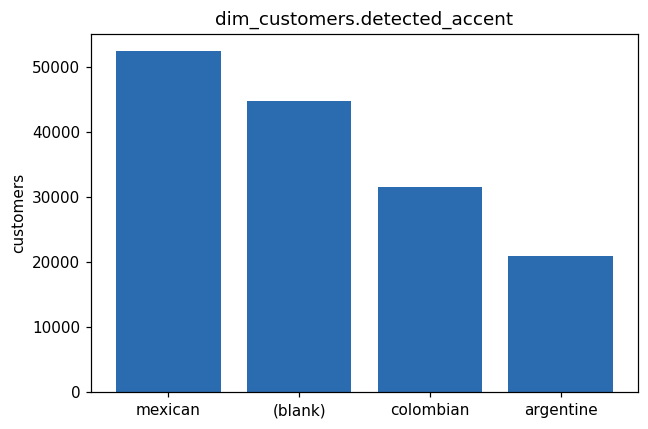

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(accent_dim["detected_accent"], accent_dim["customers"], color="#2b6cb0")
ax.set_title("dim_customers.detected_accent")
ax.set_ylabel("customers")
plt.tight_layout()
plt.show()

In [7]:
agree = con.execute(
    """
    WITH per_customer AS (
        SELECT i.customer_id,
               c.detected_accent AS profile_accent,
               mode(i.customer_detected_accent) AS interaction_mode_accent
        FROM silver.fact_call_center_interactions i
        JOIN silver.dim_customers c USING (customer_id)
        WHERE i.customer_detected_accent IS NOT NULL AND c.detected_accent IS NOT NULL
        GROUP BY 1, 2
    )
    SELECT count(*), sum(CASE WHEN profile_accent = interaction_mode_accent THEN 1 ELSE 0 END)
    FROM per_customer
    """
).fetchone()
print(f"Customers comparable: {agree[0]:,}")
print(f"Profile accent matches most-common interaction accent: {agree[1]:,} "
      f"({100*agree[1]/agree[0]:.1f}%)")
blank_profile_accent = con.execute(
    "SELECT count(*) FROM silver.dim_customers WHERE detected_accent IS NULL OR detected_accent = ''"
).fetchone()[0]
print(f"Customers with a BLANK dim_customers.detected_accent: {blank_profile_accent:,} "
      f"({100*blank_profile_accent/total_customers:.1f}%) -- these need the interaction-level fallback")

Customers comparable: 104,096
Profile accent matches most-common interaction accent: 104,096 (100.0%)
Customers with a BLANK dim_customers.detected_accent: 44,817 (29.9%) -- these need the interaction-level fallback


**Reading:** where both sources exist, they agree 100% of the time -- `dim_customers.detected_accent` is trustworthy when present. But it is blank for roughly 30% of customers, so the Gold profile needs an explicit fallback chain: `dim_customers` -> mode of interaction accent -> mode of transcript accent -> `null` (never a silently guessed default).

## 3. Language domain: Spanish/Portuguese requirement check

The hackathon requires demonstrating Spanish **and** Portuguese. This checks what language the transcripts actually contain.

In [8]:
lang = pd.read_sql(
    "SELECT detected_language, count(*) AS transcripts FROM silver.fact_call_transcripts GROUP BY 1 ORDER BY 2 DESC", con
)
lang

,detected_language,transcripts
0,es,171321


In [9]:
pt_count = con.execute(
    "SELECT count(*) FROM silver.fact_call_transcripts WHERE lower(detected_language) LIKE 'pt%'"
).fetchone()[0]
print(f"Portuguese transcripts: {pt_count:,}")

Portuguese transcripts: 0


**Reading:** every transcript is Spanish (`es`); there are zero Portuguese samples anywhere in this dataset. Portuguese personalization cannot be derived or validated from this data -- it has to be built and demonstrated with hand-authored cases, and this gap must be reported as a dataset limitation, not silently worked around.

## 4. Segment, country, and digital-channel domains

The real distinct values behind the categorical fields a tone/style rule would key off.

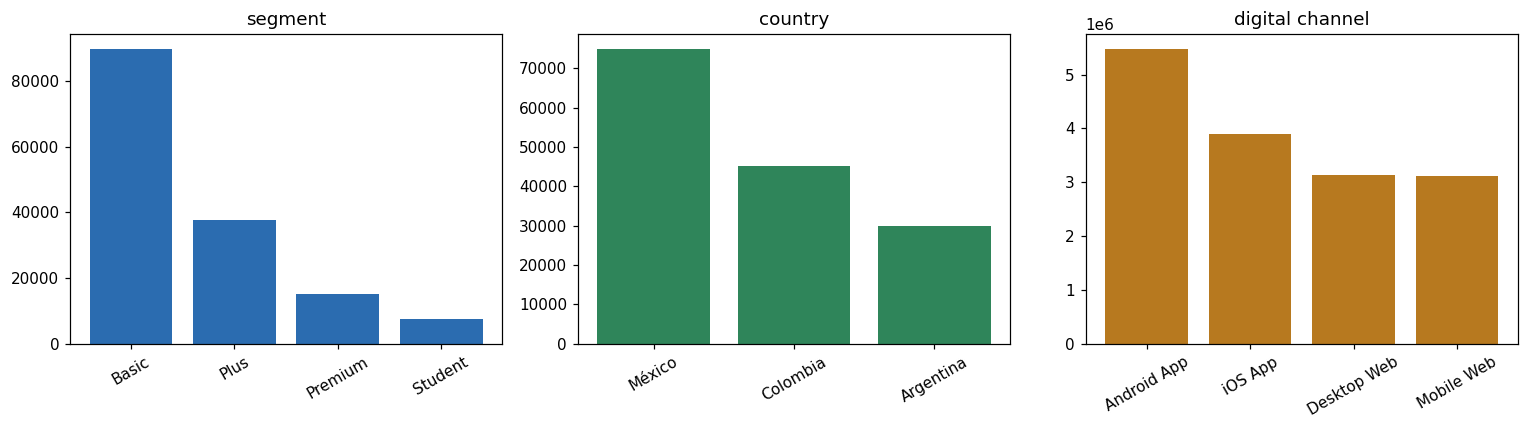

,segment,customers
0,Basic,89756
1,Plus,37547
2,Premium,15207
3,Student,7490


In [10]:
segment = pd.read_sql("SELECT segment, count(*) AS customers FROM silver.dim_customers GROUP BY 1 ORDER BY 2 DESC", con)
country = pd.read_sql("SELECT country, count(*) AS customers FROM silver.dim_customers GROUP BY 1 ORDER BY 2 DESC", con)
channel = pd.read_sql("SELECT channel, count(*) AS events FROM silver.fact_digital_events GROUP BY 1 ORDER BY 2 DESC", con)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].bar(segment["segment"], segment["customers"], color="#2b6cb0"); axes[0].set_title("segment")
axes[1].bar(country["country"], country["customers"], color="#2f855a"); axes[1].set_title("country")
axes[2].bar(channel["channel"], channel["events"], color="#b7791f"); axes[2].set_title("digital channel")
for ax in axes:
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()
segment

**Reading:** `segment` is heavily skewed toward `Basic` (60%) with `Premium` only 10% -- any segment-based tone rule will have much thinner held-out evidence for Premium/Student. Country and channel are both well-distributed and safe to key personalization on.

## 5. Repeat-contact and open-complaint signal strength

How often would a 'you've contacted us about this before' or 'you have an open case' personalization actually trigger?

In [11]:
reason_volume = pd.read_sql(
    """
    SELECT reason_category, count(*) AS interactions, count(DISTINCT customer_id) AS customers
    FROM silver.fact_call_center_interactions GROUP BY 1 ORDER BY 2 DESC
    """, con,
)
reason_volume

,reason_category,interactions,customers
0,Transaccional,240056,119646
1,Producto,150863,95245
2,Queja,117021,81336
3,Técnico,102899,74536
4,Comercial,54879,45979
5,Retención,20578,19274


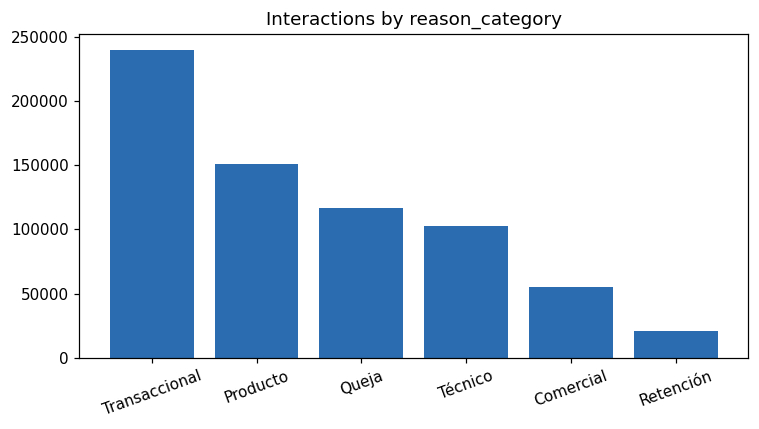

In [12]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(reason_volume["reason_category"], reason_volume["interactions"], color="#2b6cb0")
ax.set_title("Interactions by reason_category")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

In [13]:
repeat = con.execute(
    """
    WITH per_cust AS (
        SELECT customer_id, reason_category, count(*) AS n
        FROM silver.fact_call_center_interactions GROUP BY 1, 2
    )
    SELECT count(DISTINCT customer_id) FROM per_cust WHERE n >= 2
    """
).fetchone()[0]
print(f"Customers with >=2 interactions in the SAME reason_category: {repeat:,} "
      f"({100*repeat/total_customers:.1f}% of all customers)")

open_complaints = con.execute(
    "SELECT count(DISTINCT customer_id) FROM silver.fact_complaints WHERE status IN ('Open','In Process','Escalated')"
).fetchone()[0]
print(f"Customers with a currently open/in-process/escalated complaint: {open_complaints:,} "
      f"({100*open_complaints/total_customers:.1f}% of all customers)")

Customers with >=2 interactions in the SAME reason_category: 112,359 (74.9% of all customers)
Customers with a currently open/in-process/escalated complaint: 42,726 (28.5% of all customers)


**Reading:** repeat contact on the same reason is common (75% of customers, ever) -- strong, well-populated signal. An open complaint is rarer (28%) but still frequent enough to be a useful, high-priority context flag rather than an edge case.

## 6. Sentiment and CSAT coverage

Is sentiment/satisfaction data clean enough to summarize per customer?

In [14]:
sent_null = con.execute(
    "SELECT count(*), sum(CASE WHEN sentiment_score IS NULL THEN 1 ELSE 0 END) FROM silver.fact_call_center_interactions"
).fetchone()
print(f"sentiment_score null rate: {sent_null[1]:,}/{sent_null[0]:,} "
      f"({100*sent_null[1]/sent_null[0]:.1f}%)")

surveys = pd.read_sql(
    "SELECT survey_type, count(*) AS surveys, round(avg(main_score),2) AS avg_main_score "
    "FROM silver.fact_satisfaction_surveys GROUP BY 1 ORDER BY 2 DESC", con,
)
surveys

sentiment_score null rate: 0/686,296 (0.0%)


,survey_type,surveys,avg_main_score
0,CSAT,127856,2.77
1,NPS,63668,5.31
2,CES,21235,2.77


**Reading:** `sentiment_score` has zero nulls -- safe to average per customer directly. `main_score` must **not** be averaged across `survey_type` (CSAT/NPS/CES are different scales); any per-customer satisfaction summary needs one column per survey type, not one blended average.

## 7. Consent gate for proactive personalization

In [15]:
consent = pd.read_sql("SELECT accepts_marketing, count(*) AS customers FROM silver.dim_customers GROUP BY 1", con)
consent

,accepts_marketing,customers
0,False,75007
1,True,74993


**Reading:** consent is split almost exactly 50/50 and has no nulls -- a clean, reliable gate. Any *proactive* personalization (the agent bringing up something the customer didn't ask about) should be conditioned on `accepts_marketing = True`; reactive personalization (how the agent responds to a request the customer already made) does not need this gate.

## 8. Recommended variables for `gold.customer_personalization_profile`

| Variable | Source | Evidence from this analysis | Decision |
|---|---|---|---|
| `preferred_accent` | `dim_customers.detected_accent`, fallback to mode of `call_center_interactions.customer_detected_accent`, then `call_transcripts.detected_accent` | 100% agreement where both exist; ~30% blank in the dimension alone | **Include**, with explicit 3-step fallback and `null` as an honest last resort |
| `preferred_language` | `call_transcripts.detected_language` | 100% `es`, 0% `pt` | **Include for Spanish only.** Portuguese cannot be derived from data -- must ship as hand-built cases and be documented as a dataset limitation |
| `segment`, `country` | `dim_customers` | Well-populated, no nulls found | **Include** directly, no aggregation needed |
| `preferred_digital_channel` | mode of `fact_digital_events.channel` | 100% coverage, well-distributed across 4 channels | **Include** |
| `repeat_contact_flag` (per `reason_category`) | `fact_call_center_interactions` | 75% of customers qualify -- strong, common signal | **Include** |
| `open_complaint_flag` | `fact_complaints.status` | 28% of customers -- meaningful minority, not a rare edge case | **Include** |
| `avg_sentiment_score` | `fact_call_center_interactions.sentiment_score` | 0% null, 99% customer coverage | **Include** |
| `csat_avg`, `nps_avg`, `ces_avg` (separate columns) | `fact_satisfaction_surveys`, split by `survey_type` | Scales differ per type; blending would be wrong | **Include as 3 separate columns**, never one blended average |
| `accepts_marketing` | `dim_customers` | Clean 50/50 split, no nulls | **Include as a gate**, not a personalization style itself |
| `credit_score`, `estimated_monthly_income`, `fraud_score`, `days_past_due` | `dim_customers` / `products` / `transactions` | Out of scope by team decision | **Excluded** -- risk-based personalization was deliberately deferred |

None of these signals require joining fact tables to each other directly -- each is aggregated to `customer_id` grain independently before any join, per the project's existing join-safety rule.